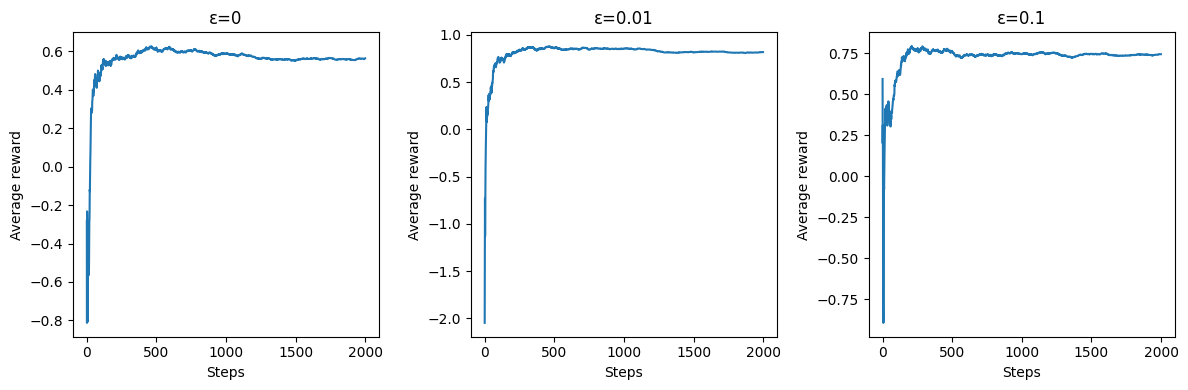

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Tạo bài toán bandit 10 tay
n_actions = 10
q_true = np.random.normal(0, 1, n_actions)  # giá trị thực của mỗi tay
optimal_action = np.argmax(q_true)

def epsilon_greedy(epsilon, n_steps=1000):
    Q = np.zeros(n_actions)          # ước lượng giá trị
    counts = np.zeros(n_actions)     # số lần chọn mỗi tay
    rewards = []
    optimal_counts = []
    for t in range(1, n_steps+1):
        # Chọn hành động
        if np.random.rand() < epsilon:
            a = np.random.randint(n_actions)
        else:
            a = np.argmax(Q)
        # Nhận phần thưởng
        reward = np.random.normal(q_true[a], 1)
        # Cập nhật
        counts[a] += 1
        Q[a] += (reward - Q[a]) / counts[a]
        rewards.append(reward)
        optimal_counts.append(1 if a == optimal_action else 0)
    return rewards, optimal_counts

# Thử nghiệm với 3 giá trị epsilon
epsilons = [0, 0.01, 0.1]
plt.figure(figsize=(12,4))
for i, eps in enumerate(epsilons):
    rewards, opts = epsilon_greedy(eps, 2000)
    cum_avg = np.cumsum(rewards) / np.arange(1, len(rewards)+1)
    plt.subplot(1,3,i+1)
    plt.plot(cum_avg)
    plt.title(f'ε={eps}')
    plt.xlabel('Steps')
    plt.ylabel('Average reward')
plt.tight_layout()
plt.show()